In [10]:
text=["All that we are is a result of what we have thought","To be or not to be, that is the question","Be yourself, everyone else is already taken"]

import re
re.split('\s',text[0])

['All',
 'that',
 'we',
 'are',
 'is',
 'a',
 'result',
 'of',
 'what',
 'we',
 'have',
 'thought']

In [3]:
' '.join(re.split('\s',text[0]))
allwords=re.split('\s',' '.join(text).lower())
print(allwords)

['all', 'that', 'we', 'are', 'is', 'a', 'result', 'of', 'what', 'we', 'have', 'thought', 'to', 'be', 'or', 'not', 'to', 'be,', 'that', 'is', 'the', 'question', 'be', 'yourself,', 'everyone', 'else', 'is', 'already', 'taken']


In [4]:
vocab=sorted(set(allwords))
print(vocab)
print(len(vocab))
print(len(allwords))

['a', 'all', 'already', 'are', 'be', 'be,', 'else', 'everyone', 'have', 'is', 'not', 'of', 'or', 'question', 'result', 'taken', 'that', 'the', 'thought', 'to', 'we', 'what', 'yourself,']
23
29


In [5]:
word2idx={word:i for i,word in enumerate(vocab)}
idx2word={i:word for i,word in enumerate(vocab)}
print(word2idx)
print(idx2word)

{'a': 0, 'all': 1, 'already': 2, 'are': 3, 'be': 4, 'be,': 5, 'else': 6, 'everyone': 7, 'have': 8, 'is': 9, 'not': 10, 'of': 11, 'or': 12, 'question': 13, 'result': 14, 'taken': 15, 'that': 16, 'the': 17, 'thought': 18, 'to': 19, 'we': 20, 'what': 21, 'yourself,': 22}
{0: 'a', 1: 'all', 2: 'already', 3: 'are', 4: 'be', 5: 'be,', 6: 'else', 7: 'everyone', 8: 'have', 9: 'is', 10: 'not', 11: 'of', 12: 'or', 13: 'question', 14: 'result', 15: 'taken', 16: 'that', 17: 'the', 18: 'thought', 19: 'to', 20: 'we', 21: 'what', 22: 'yourself,'}


In [7]:
import numpy as np

randidx=np.random.randint(0,len(vocab),10)
print(randidx)
print(" ".join([idx2word[i] for i in randidx]))

[16  2 10 19 18 17 22 16 17  9]
that already not to thought the yourself, that the is


In [8]:
import matplotlib.pyplot as plt
import matplotlib_inline.backend_inline 
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

In [14]:
def encoder(text):
    allwords=re.split('\s',text.lower())
    return [word2idx[word] for word in allwords]

def decoder(idx):
    return " ".join([idx2word[i] for i in idx])

print(decoder(encoder("All that we are is a result of what we have thought")))

all that we are is a result of what we have thought


Visualize Tokens


[1, 16, 20, 3, 9, 0, 14, 11, 21, 20, 8, 18, 19, 4, 12, 10, 19, 5, 16, 9, 17, 13, 4, 22, 7, 6, 9, 2, 15]


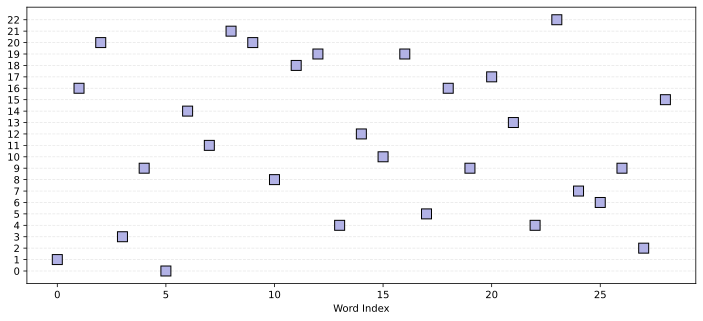

In [25]:
all_text=" ".join(text)
tokens=encoder(all_text)
print(tokens)
_, ax = plt.subplots(1,1, figsize=(12, 5))
ax.plot(tokens,'ks',markersize=10,markerfacecolor=[.7,.7,.9])
ax.set(xlabel="Word Index",yticks=range(len(vocab)))
ax.grid(linestyle='--',alpha=.3,axis='y')
plt.show()


ax2=ax.twinx()
ax2.plot(tokens,alpha=0)
ax2.set(yticks=range(len(vocab)),yticklabels=vocab)

plt.show()

Print indices of a word and its respective  context and target 

In [52]:
target_word="to"
target_locs=np.where(np.array(allwords)==target_word)[0]
print(f"The ordinal positions of target word are: {target_locs}")

print("Printing the context and target for each occurence of the target word:")

for i in target_locs:
    print(tokens[i-1:i+2])
    print(f"Target: {target_word} \n Context: {allwords[i-1]} {allwords[i+1]}")
    

The ordinal positions of target word are: [12 16]
Printing the context and target for each occurence of the target word:
[18, 19, 4]
Target: to 
 Context: thought be
[10, 19, 5]
Target: to 
 Context: not be,


In [54]:
word_matrix=np.zeros((len(allwords),len(vocab)),dtype=int)
for i,word in enumerate(allwords):
    word_matrix[i,word2idx[word]]=1
print(word_matrix)



[[0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0]
 [0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0]
 [0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0]
 [0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0]
 [0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 

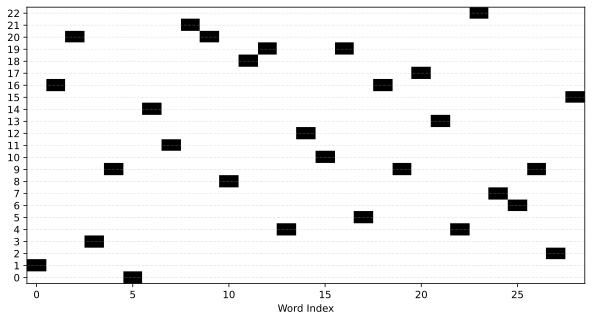

In [62]:
_,ax=plt.subplots(1,1,figsize=(10,5))
plt.imshow(1-word_matrix.T,cmap='gray',origin='lower',aspect='auto')
ax.set(xlabel="Word Index",yticks=range(len(vocab)))
ax.grid(linestyle='--',alpha=.3,axis='y')
plt.show()